<a href="https://colab.research.google.com/github/machiwao/CCRNFLRL_Integer_Damath/blob/eco/Damath_ActorCritic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import matplotlib.pyplot as plt
from copy import deepcopy

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

In [3]:
class IntegerDamathEnv:
    """
    Integer Damath Environment (Grade 7 variant)
    Combines checkers movement with arithmetic operations
    """
    def __init__(self):
        self.board_size = 8
        self.reset()

        # Fixed Damath board template
        self.initial_board_template = [
            [2, "#", -5, "#", 8, "#", -11, "#"],
            ["#", -7, "#", 10, "#", -3, "#", 0],
            [4, "#", -1, "#", 9, "#", -6, "#"],
            ["#", "#", "#", "#", "#", "#", "#", "#"],
            ["#", "#", "#", "#", "#", "#", "#", "#"],
            ["#", -9, "#", 6, "#", -1, "#", 4],
            [0, "#", -3, "#", 10, "#", -7, "#"],
            ["#", -11, "#", 8, "#", -5, "#", 2]
        ]

        # Operations board
        self.operations_board = [
            ["+", "#", "÷", "#", "-", "#", "×", "#"],
            ["#", "×", "#", "+", "#", "÷", "#", "-"],
            ["-", "#", "+", "#", "÷", "#", "×", "#"],
            ["#", "÷", "#", "-", "#", "×", "#", "+"],
            ["×", "#", "÷", "#", "-", "#", "+", "#"],
            ["#", "+", "#", "÷", "#", "-", "#", "×"],
            ["÷", "#", "×", "#", "+", "#", "-", "#"],
            ["#", "-", "#", "×", "#", "+", "#", "÷"],
        ]

    def reset(self):
        """Reset the game to initial state"""
        self.board = np.zeros((8, 8), dtype=object)
        self.piece_types = np.zeros((8, 8), dtype=int)  # 0: empty, 1: regular, 2: dama

        # Initialize pieces for Player 1 (top, moving down)
        player1_positions = [
            (0, 0, 2), (0, 2, -5), (0, 4, 8), (0, 6, -11),
            (1, 1, -7), (1, 3, 10), (1, 5, -3), (1, 7, 0),
            (2, 0, 4), (2, 2, -1), (2, 4, 9), (2, 6, -6)
        ]

        # Initialize pieces for Player 2 (bottom, moving up)
        player2_positions = [
            (5, 1, -9), (5, 3, 6), (5, 5, -1), (5, 7, 4),
            (6, 0, 0), (6, 2, -3), (6, 4, 10), (6, 6, -7),
            (7, 1, -11), (7, 3, 8), (7, 5, -5), (7, 7, 2)
        ]

        for r, c, val in player1_positions:
            self.board[r, c] = (1, val)  # (player, value)
            self.piece_types[r, c] = 1

        for r, c, val in player2_positions:
            self.board[r, c] = (2, val)  # (player, value)
            self.piece_types[r, c] = 1

        self.current_player = 1
        self.scores = {1: 0, 2: 0}
        self.game_over = False
        self.winner = None
        self.moves_without_capture = 0
        self.max_moves_without_capture = 50

        return self.get_state()

    def get_state(self):
        """Convert board to state representation for neural network"""
        # Create separate channels for player 1, player 2, damas, and values
        state = np.zeros((6, 8, 8), dtype=np.float32)

        for r in range(8):
            for c in range(8):
                if self.board[r, c] != 0:
                    player, value = self.board[r, c]
                    if player == 1:
                        state[0, r, c] = 1  # Player 1 pieces
                        state[2, r, c] = value / 11.0  # Normalized value
                    else:
                        state[1, r, c] = 1  # Player 2 pieces
                        state[3, r, c] = value / 11.0  # Normalized value

                    if self.piece_types[r, c] == 2:
                        state[4, r, c] = 1  # Dama pieces

        # Current player indicator
        state[5, :, :] = self.current_player

        return state

    def get_legal_moves(self, player=None):
        """Get all legal moves for the current player"""
        if player is None:
            player = self.current_player

        moves = []
        mandatory_captures = []

        for r in range(8):
            for c in range(8):
                if self.board[r, c] != 0 and self.board[r, c][0] == player:
                    piece_moves = self._get_piece_moves(r, c)
                    for move in piece_moves:
                        if move['is_capture']:
                            mandatory_captures.append(move)
                        else:
                            moves.append(move)

        # In Damath, captures are mandatory if available
        return mandatory_captures if mandatory_captures else moves

    def _get_piece_moves(self, r, c):
        """Get all legal moves for a piece at position (r, c)"""
        moves = []
        player, value = self.board[r, c]
        is_dama = self.piece_types[r, c] == 2

        # Direction based on player and piece type
        if is_dama:
            directions = [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        else:
            directions = [(-1, -1), (-1, 1)] if player == 2 else [(1, -1), (1, 1)]

        for dr, dc in directions:
            # Simple move
            nr, nc = r + dr, c + dc
            if 0 <= nr < 8 and 0 <= nc < 8 and self.board[nr, nc] == 0:
                moves.append({
                    'from': (r, c),
                    'to': (nr, nc),
                    'is_capture': False,
                    'captured_pos': None,
                    'score': 0
                })

            # Capture move
            nr, nc = r + dr, c + dc
            jump_r, jump_c = r + 2*dr, c + 2*dc
            if (0 <= nr < 8 and 0 <= nc < 8 and
                0 <= jump_r < 8 and 0 <= jump_c < 8 and
                self.board[nr, nc] != 0 and
                self.board[nr, nc][0] != player and
                self.board[jump_r, jump_c] == 0):

                # Calculate score for this capture
                captured_value = self.board[nr, nc][1]
                operation = self.operations_board[nr][nc]
                score = self._calculate_score(value, captured_value, operation)

                moves.append({
                    'from': (r, c),
                    'to': (jump_r, jump_c),
                    'is_capture': True,
                    'captured_pos': (nr, nc),
                    'score': score
                })

        return moves

    def _calculate_score(self, attacker_val, defender_val, operation):
        """Calculate score based on arithmetic operation"""
        try:
            if operation == '+':
                return attacker_val + defender_val
            elif operation == '-':
                return attacker_val - defender_val
            elif operation == '×':
                return attacker_val * defender_val
            elif operation == '÷':
                if defender_val != 0:
                    return int(attacker_val / defender_val)
                return 0
        except:
            return 0
        return 0

    def step(self, move):
        """Execute a move and return (next_state, reward, done, info)"""
        if self.game_over:
            return self.get_state(), 0, True, {}

        from_pos = move['from']
        to_pos = move['to']
        is_capture = move['is_capture']

        # Move the piece
        player, value = self.board[from_pos]
        piece_type = self.piece_types[from_pos]

        self.board[to_pos] = self.board[from_pos]
        self.piece_types[to_pos] = piece_type
        self.board[from_pos] = 0
        self.piece_types[from_pos] = 0

        reward = 0

        # Handle capture
        if is_capture:
            captured_pos = move['captured_pos']
            self.board[captured_pos] = 0
            self.piece_types[captured_pos] = 0

            score = move['score']
            self.scores[player] += score
            reward = score

            # Bonus for dama capture
            if piece_type == 2:
                reward += 2

            self.moves_without_capture = 0
        else:
            self.moves_without_capture += 1

        # Check for promotion to dama
        if player == 1 and to_pos[0] == 7 and piece_type == 1:
            self.piece_types[to_pos] = 2
            reward += 5
        elif player == 2 and to_pos[0] == 0 and piece_type == 1:
            self.piece_types[to_pos] = 2
            reward += 5

        # Check game end conditions
        self._check_game_over()

        # Switch player
        self.current_player = 3 - self.current_player

        return self.get_state(), reward, self.game_over, {'winner': self.winner}

    def _check_game_over(self):
        """Check if the game is over"""
        # Count pieces
        p1_pieces = np.sum((self.board != 0) & (np.vectorize(lambda x: x[0] if x != 0 else 0)(self.board) == 1))
        p2_pieces = np.sum((self.board != 0) & (np.vectorize(lambda x: x[0] if x != 0 else 0)(self.board) == 2))

        # Game over if one player has no pieces
        if p1_pieces == 0:
            self.game_over = True
            self.winner = 2
            return
        if p2_pieces == 0:
            self.game_over = True
            self.winner = 1
            return

        # Game over if no legal moves
        if len(self.get_legal_moves(1)) == 0:
            self.game_over = True
            self.winner = 2
            return
        if len(self.get_legal_moves(2)) == 0:
            self.game_over = True
            self.winner = 1
            return

        # Draw if too many moves without capture
        if self.moves_without_capture >= self.max_moves_without_capture:
            self.game_over = True
            self.winner = 1 if self.scores[1] > self.scores[2] else 2
            if self.scores[1] == self.scores[2]:
                self.winner = 0  # Draw

    def render(self):
        """Print the current board state"""
        print("\n" + "="*50)
        print(f"Current Player: {self.current_player}")
        print(f"Scores - Player 1: {self.scores[1]} | Player 2: {self.scores[2]}")
        print("="*50)
        print("   0   1   2   3   4   5   6   7")

        for r in range(8):
            row_str = f"{r} "
            for c in range(8):
                if self.board[r, c] == 0:
                    row_str += " .  "
                else:
                    player, value = self.board[r, c]
                    dama = "D" if self.piece_types[r, c] == 2 else ""
                    symbol = "↓" if player == 1 else "↑"
                    row_str += f"{symbol}{value:2d}{dama} "[:4]
            print(row_str)
        print()

In [4]:
class ActorCriticNetwork(nn.Module):
    """
    Combined Actor-Critic network for Damath
    """
    def __init__(self, input_channels=6, board_size=8):
        super(ActorCriticNetwork, self).__init__()

        # Shared convolutional layers
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        # Actor head (policy)
        self.actor_conv = nn.Conv2d(128, 64, kernel_size=1)
        self.actor_fc = nn.Linear(64 * board_size * board_size, 512)
        self.actor_out = nn.Linear(512, board_size * board_size * 4)  # from_pos + direction

        # Critic head (value)
        self.critic_conv = nn.Conv2d(128, 32, kernel_size=1)
        self.critic_fc = nn.Linear(32 * board_size * board_size, 256)
        self.critic_out = nn.Linear(256, 1)

    def forward(self, x):
        # Shared layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))

        # Actor
        actor = F.relu(self.actor_conv(x))
        actor = actor.view(actor.size(0), -1)
        actor = F.relu(self.actor_fc(actor))
        policy_logits = self.actor_out(actor)

        # Critic
        critic = F.relu(self.critic_conv(x))
        critic = critic.view(critic.size(0), -1)
        critic = F.relu(self.critic_fc(critic))
        value = self.critic_out(critic)

        return policy_logits, value

In [5]:
class ActorCriticAgent:
    """
    Actor-Critic Agent for Integer Damath
    """
    def __init__(self, lr=0.0003, gamma=0.99, entropy_coef=0.01):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.network = ActorCriticNetwork().to(self.device)
        self.optimizer = optim.Adam(self.network.parameters(), lr=lr)
        self.gamma = gamma
        self.entropy_coef = entropy_coef

        self.saved_log_probs = []
        self.saved_values = []
        self.rewards = []

    def select_action(self, state, legal_moves, training=True):
        """Select an action using the policy network"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)

        with torch.no_grad() if not training else torch.enable_grad():
            policy_logits, value = self.network(state_tensor)

        # Create mask for legal moves
        mask = self._create_move_mask(legal_moves)
        mask_tensor = torch.FloatTensor(mask).to(self.device)

        # Apply mask (set illegal moves to large negative number)
        masked_logits = policy_logits + (mask_tensor - 1) * 1e9

        # Sample action
        probs = F.softmax(masked_logits, dim=-1)

        if training:
            dist = torch.distributions.Categorical(probs)
            action_idx = dist.sample()
            log_prob = dist.log_prob(action_idx)

            self.saved_log_probs.append(log_prob)
            self.saved_values.append(value)
        else:
            action_idx = torch.argmax(probs)

        # Convert action index to move
        move = self._action_idx_to_move(action_idx.item(), legal_moves)

        return move

    def _create_move_mask(self, legal_moves):
        """Create a binary mask for legal moves"""
        mask = np.zeros(8 * 8 * 4)
        for move in legal_moves:
            idx = self._move_to_action_idx(move)
            if idx < len(mask):
                mask[idx] = 1
        return mask

    def _move_to_action_idx(self, move):
        """Convert move to action index"""
        from_r, from_c = move['from']
        to_r, to_c = move['to']

        # Encode direction
        dr, dc = to_r - from_r, to_c - from_c
        if abs(dr) == 2:  # Capture move
            dr, dc = dr // 2, dc // 2

        direction_map = {(-1, -1): 0, (-1, 1): 1, (1, -1): 2, (1, 1): 3}
        direction = direction_map.get((dr, dc), 0)

        return from_r * 8 * 4 + from_c * 4 + direction

    def _action_idx_to_move(self, action_idx, legal_moves):
        """Convert action index back to move"""
        if len(legal_moves) == 0:
            return None

        # Find closest matching move
        best_move = legal_moves[0]
        min_diff = float('inf')

        for move in legal_moves:
            move_idx = self._move_to_action_idx(move)
            diff = abs(move_idx - action_idx)
            if diff < min_diff:
                min_diff = diff
                best_move = move

        return best_move

    def store_reward(self, reward):
        """Store reward for this step"""
        self.rewards.append(reward)

    def update(self):
        """Update the network using collected experience"""
        if len(self.rewards) == 0:
            return 0

        R = 0
        returns = []

        # Calculate discounted returns
        for r in reversed(self.rewards):
            R = r + self.gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns).to(self.device)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        policy_losses = []
        value_losses = []

        for log_prob, value, R in zip(self.saved_log_probs, self.saved_values, returns):
            advantage = R - value.item()

            # Actor loss
            policy_losses.append(-log_prob * advantage)

            # Critic loss
            value_losses.append(F.smooth_l1_loss(value.squeeze(), torch.tensor([R]).to(self.device)))

        self.optimizer.zero_grad()

        loss = (torch.stack(policy_losses).sum() +
                torch.stack(value_losses).sum())

        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.network.parameters(), 0.5)
        self.optimizer.step()

        # Clear memory
        self.saved_log_probs = []
        self.saved_values = []
        self.rewards = []

        return loss.item()

    def save(self, path):
        """Save model"""
        torch.save(self.network.state_dict(), path)

    def load(self, path):
        """Load model"""
        self.network.load_state_dict(torch.load(path))

In [6]:
def train_actor_critic(num_episodes=1000, render_every=100):
    """
    Train two Actor-Critic agents to play Damath against each other
    """
    env = IntegerDamathEnv()
    agent1 = ActorCriticAgent(lr=0.0003)
    agent2 = ActorCriticAgent(lr=0.0003)

    episode_rewards = []
    episode_lengths = []
    wins = {1: 0, 2: 0, 0: 0}

    print("Starting Actor-Critic Training for Integer Damath")
    print("="*60)

    for episode in range(num_episodes):
        state = env.reset()
        episode_reward = 0
        steps = 0

        while not env.game_over and steps < 200:
            current_agent = agent1 if env.current_player == 1 else agent2
            opponent_agent = agent2 if env.current_player == 1 else agent1

            legal_moves = env.get_legal_moves()
            if len(legal_moves) == 0:
                break

            move = current_agent.select_action(state, legal_moves, training=True)
            next_state, reward, done, info = env.step(move)

            # Store reward for current agent
            current_agent.store_reward(reward)
            # Opponent gets negative reward
            opponent_agent.store_reward(-reward)

            episode_reward += reward
            state = next_state
            steps += 1

        # Update both agents
        loss1 = agent1.update()
        loss2 = agent2.update()

        # Record statistics
        episode_rewards.append(episode_reward)
        episode_lengths.append(steps)
        winner = env.winner if env.winner is not None else 0
        wins[winner] += 1

        # Print progress
        if (episode + 1) % 10 == 0:
            avg_reward = np.mean(episode_rewards[-10:])
            avg_length = np.mean(episode_lengths[-10:])
            print(f"Episode {episode+1}/{num_episodes} | "
                  f"Avg Reward: {avg_reward:.2f} | "
                  f"Avg Length: {avg_length:.1f} | "
                  f"Wins - P1: {wins[1]} P2: {wins[2]} Draw: {wins[0]}")

        # Render game occasionally
        if (episode + 1) % render_every == 0:
            print(f"\n--- Game at Episode {episode+1} ---")
            env.render()

    # Plot training progress
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(episode_rewards)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Episode Rewards Over Time')

    plt.subplot(1, 3, 2)
    plt.plot(episode_lengths)
    plt.xlabel('Episode')
    plt.ylabel('Steps')
    plt.title('Episode Length Over Time')

    plt.subplot(1, 3, 3)
    labels = ['Player 1', 'Player 2', 'Draw']
    values = [wins[1], wins[2], wins[0]]
    plt.bar(labels, values)
    plt.ylabel('Number of Wins')
    plt.title('Win Distribution')

    plt.tight_layout()
    plt.show()

    return agent1, agent2, env

In [7]:
def play_demo_game(agent1, agent2):
    """Play a demonstration game between two trained agents"""
    env = IntegerDamathEnv()
    state = env.reset()

    print("\n" + "="*60)
    print("DEMONSTRATION GAME: Trained Agents Playing")
    print("="*60)

    env.render()
    step = 0

    while not env.game_over and step < 200:
        current_agent = agent1 if env.current_player == 1 else agent2
        legal_moves = env.get_legal_moves()

        if len(legal_moves) == 0:
            break

        move = current_agent.select_action(state, legal_moves, training=False)
        state, reward, done, info = env.step(move)

        print(f"\nStep {step + 1}: Player {3 - env.current_player} moves")
        print(f"From {move['from']} to {move['to']}")
        if move['is_capture']:
            print(f"Captured at {move['captured_pos']} for {move['score']} points!")

        env.render()
        step += 1

        if step % 10 == 0:
            input("Press Enter to continue...")

    print("\n" + "="*60)
    print("GAME OVER!")
    print(f"Winner: Player {env.winner if env.winner != 0 else 'Draw'}")
    print(f"Final Scores - Player 1: {env.scores[1]} | Player 2: {env.scores[2]}")
    print("="*60)

Starting Actor-Critic Training for Integer Damath


/tmp/ipython-input-3036765406.py:120: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  value_losses.append(F.smooth_l1_loss(value.squeeze(), torch.tensor([R]).to(self.device)))


Episode 10/500 | Avg Reward: 62.80 | Avg Length: 86.4 | Wins - P1: 6 P2: 4 Draw: 0
Episode 20/500 | Avg Reward: 76.90 | Avg Length: 91.8 | Wins - P1: 11 P2: 9 Draw: 0
Episode 30/500 | Avg Reward: 36.80 | Avg Length: 83.2 | Wins - P1: 17 P2: 13 Draw: 0
Episode 40/500 | Avg Reward: 18.70 | Avg Length: 71.6 | Wins - P1: 22 P2: 18 Draw: 0
Episode 50/500 | Avg Reward: 5.40 | Avg Length: 79.8 | Wins - P1: 27 P2: 23 Draw: 0
Episode 60/500 | Avg Reward: 20.10 | Avg Length: 72.7 | Wins - P1: 33 P2: 27 Draw: 0
Episode 70/500 | Avg Reward: 15.20 | Avg Length: 65.4 | Wins - P1: 38 P2: 32 Draw: 0
Episode 80/500 | Avg Reward: 37.20 | Avg Length: 84.3 | Wins - P1: 45 P2: 35 Draw: 0
Episode 90/500 | Avg Reward: -15.70 | Avg Length: 90.2 | Wins - P1: 48 P2: 42 Draw: 0
Episode 100/500 | Avg Reward: 59.70 | Avg Length: 72.9 | Wins - P1: 56 P2: 44 Draw: 0

--- Game at Episode 100 ---

Current Player: 1
Scores - Player 1: -69 | Player 2: -93
   0   1   2   3   4   5   6   7
0 ↑10D .   .   .   .   .   .   .

/tmp/ipython-input-3036765406.py:120: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  value_losses.append(F.smooth_l1_loss(value.squeeze(), torch.tensor([R]).to(self.device)))


Episode 110/500 | Avg Reward: 35.40 | Avg Length: 78.1 | Wins - P1: 61 P2: 49 Draw: 0
Episode 120/500 | Avg Reward: 1.50 | Avg Length: 66.5 | Wins - P1: 68 P2: 52 Draw: 0
Episode 130/500 | Avg Reward: 7.40 | Avg Length: 89.4 | Wins - P1: 73 P2: 57 Draw: 0
Episode 140/500 | Avg Reward: 71.10 | Avg Length: 84.5 | Wins - P1: 78 P2: 62 Draw: 0
Episode 150/500 | Avg Reward: 5.70 | Avg Length: 66.1 | Wins - P1: 83 P2: 67 Draw: 0
Episode 160/500 | Avg Reward: 39.10 | Avg Length: 68.6 | Wins - P1: 87 P2: 73 Draw: 0
Episode 170/500 | Avg Reward: 88.30 | Avg Length: 66.8 | Wins - P1: 91 P2: 79 Draw: 0
Episode 180/500 | Avg Reward: 44.70 | Avg Length: 74.4 | Wins - P1: 97 P2: 83 Draw: 0
Episode 190/500 | Avg Reward: 41.30 | Avg Length: 73.6 | Wins - P1: 101 P2: 89 Draw: 0
Episode 200/500 | Avg Reward: -6.00 | Avg Length: 71.7 | Wins - P1: 106 P2: 94 Draw: 0

--- Game at Episode 200 ---

Current Player: 1
Scores - Player 1: 2 | Player 2: 36
   0   1   2   3   4   5   6   7
0  .   .   .   .   .   .

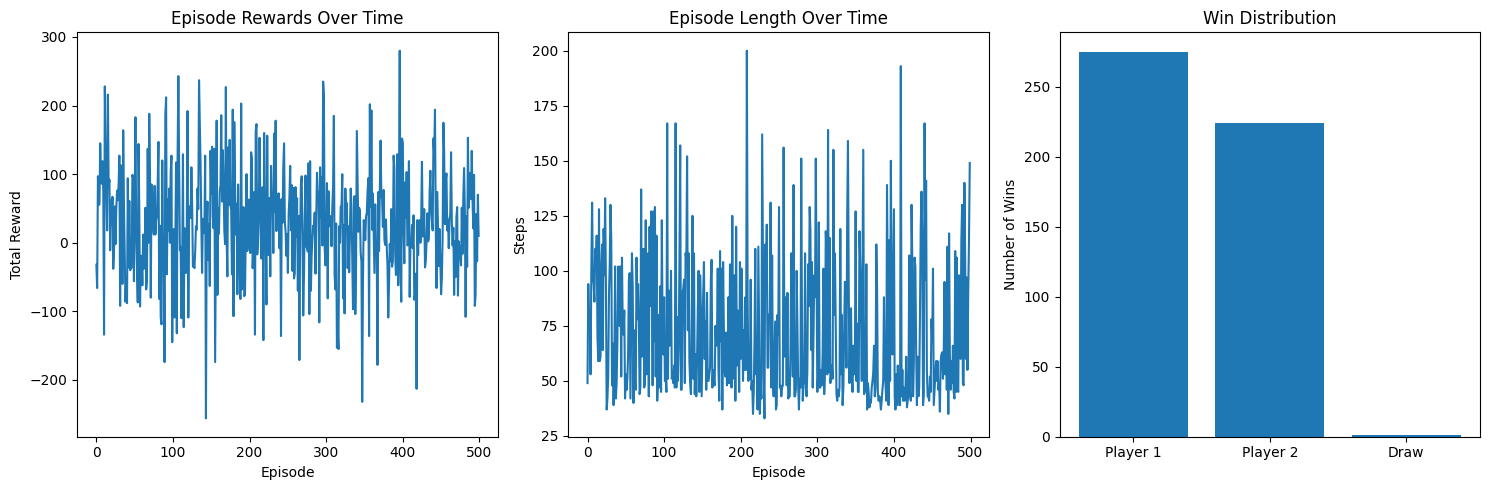


DEMONSTRATION GAME: Trained Agents Playing

Current Player: 1
Scores - Player 1: 0 | Player 2: 0
   0   1   2   3   4   5   6   7
0 ↓ 2  .  ↓-5  .  ↓ 8  .  ↓-11 .  
1  .  ↓-7  .  ↓10  .  ↓-3  .  ↓ 0 
2 ↓ 4  .  ↓-1  .  ↓ 9  .  ↓-6  .  
3  .   .   .   .   .   .   .   .  
4  .   .   .   .   .   .   .   .  
5  .  ↑-9  .  ↑ 6  .  ↑-1  .  ↑ 4 
6 ↑ 0  .  ↑-3  .  ↑10  .  ↑-7  .  
7  .  ↑-11 .  ↑ 8  .  ↑-5  .  ↑ 2 


Step 1: Player 1 moves
From (2, 2) to (3, 3)

Current Player: 2
Scores - Player 1: 0 | Player 2: 0
   0   1   2   3   4   5   6   7
0 ↓ 2  .  ↓-5  .  ↓ 8  .  ↓-11 .  
1  .  ↓-7  .  ↓10  .  ↓-3  .  ↓ 0 
2 ↓ 4  .   .   .  ↓ 9  .  ↓-6  .  
3  .   .   .  ↓-1  .   .   .   .  
4  .   .   .   .   .   .   .   .  
5  .  ↑-9  .  ↑ 6  .  ↑-1  .  ↑ 4 
6 ↑ 0  .  ↑-3  .  ↑10  .  ↑-7  .  
7  .  ↑-11 .  ↑ 8  .  ↑-5  .  ↑ 2 


Step 2: Player 2 moves
From (5, 7) to (4, 6)

Current Player: 1
Scores - Player 1: 0 | Player 2: 0
   0   1   2   3   4   5   6   7
0 ↓ 2  .  ↓-5  .  ↓ 8  .  ↓-11 .  
1  .  

In [8]:
# Main execution
if __name__ == "__main__":
    # Train the agents
    agent1, agent2, env = train_actor_critic(num_episodes=500, render_every=100)

    # Play a demo game
    play_demo_game(agent1, agent2)

    # Save the trained models
    agent1.save('damath_agent1.pth')
    agent2.save('damath_agent2.pth')
    print("\nModels saved successfully!")